<a href="https://colab.research.google.com/github/serdararici/breast-cancer-knn-svm-classification/blob/main/Breast_Cancer_KNN_vs_SVM_HSD_Bootcamp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Meme Kanseri Teşhisinde Makine Öğrenmesi: KNN vs SVM Karşılaştırması

**Huawei Student Developers – Veri Bilimi ve Makine Öğrenmesi Bootcamp Final Projesi**

---

**Hazırlayan:** Serdar Arıcı
**Tarih:** Ağustos 2026
**Bootcamp:** Türkiye Yapay Zeka Akademisi × Huawei Student Developers — Veri Bilimi ve Makine Öğrenmesi Bootcamp

---

## 📌 Proje Amacı

Bu projede, **Breast Cancer Wisconsin (Diagnostic) Dataset** kullanılarak, hücre çekirdeği ölçümlerinden yola çıkarak bir tümörün **iyi huylu (benign)** mu yoksa **kötü huylu (malignant)** mu olduğunu tahmin eden bir sınıflandırma modeli geliştirilecektir.

İki farklı makine öğrenmesi algoritması — **K-En Yakın Komşu (KNN)** ve **Destek Vektör Makineleri (SVM)** — eğitilecek, hiperparametreleri optimize edilecek ve performansları çeşitli metriklerle karşılaştırılacaktır.

## 📊 Veri Seti Hakkında

- **Kaynak:** [Kaggle - Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)
- **Gözlem sayısı:** 569
- **Özellik sayısı:** 30 sayısal özellik (hücre çekirdeğinin yarıçapı, dokusu, çevresi, alanı, pürüzsüzlüğü vb. ölçümlerin ortalama, standart hata ve "en kötü" değerleri)
- **Hedef değişken:** `diagnosis` — M (Malignant / Kötü Huylu) veya B (Benign / İyi Huylu)

## 🛠️ İzlenecek Yol

1. Veri Yükleme ve Genel Bakış
2. Keşifsel Veri Analizi (EDA)
3. Veri Ön İşleme
4. Model 1: K-En Yakın Komşu (KNN)
5. Model 2: Destek Vektör Makineleri (SVM)
6. Model Karşılaştırması ve Değerlendirme
7. Sonuç ve Çıkarımlar

---

## 🔧 Gerekli Kütüphanelerin Yüklenmesi

Analiz, modelleme ve görselleştirme için kullanacağımız kütüphaneleri içe aktarıyoruz.

In [1]:
# Data manipulation libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing, models, and evaluation metrics
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay
)

# Set plotting style for a clean and professional look
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11

# Fix random seed for reproducibility across the whole notebook
RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


## 1️⃣ Veri Yükleme ve Genel Bakış

Veri setini Google Drive üzerinden Colab ortamına bağlayarak okuyoruz. Veri seti, Kaggle'daki "Breast Cancer Wisconsin (Diagnostic) Data Set" kaynağından indirilmiştir.

In [6]:
# Mount Google Drive to access the dataset file
from google.colab import drive
drive.mount('/content/drive')

# Define the path to the dataset on Google Drive
DATA_PATH = "/content/drive/MyDrive/MachineLearning-AI-DataScience/TurkiyeYapayZekaAkademisi/finalProject/data.csv"

# Load the dataset into a pandas DataFrame
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Veri setinde **569 gözlem** ve **569 hasta kaydı, 30 sayısal özellik** bulunuyor. `id` sütunu sadece hasta kimlik numarası (modelleme için anlamsız), `Unnamed: 32` sütunu ise tamamen boş görünüyor — bu iki sütunu veri temizliği aşamasında çıkaracağız.

Her özellik, hücre çekirdeğinin bir karakteristiğini (yarıçap, doku, çevre, alan, pürüzsüzlük vb.) üç farklı istatistik üzerinden ifade ediyor: ortalama (`mean`), standart hata (`se`), ve en kötü değer (`worst`).

In [7]:
# General information about the dataset: column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [8]:
# Drop irrelevant columns:
# - 'id' is just a patient identifier, not useful for prediction
# - 'Unnamed: 32' is a completely empty column (artifact of the CSV export)
df = df.drop(columns=["id", "Unnamed: 32"])

print(f"Dataset shape after cleanup: {df.shape}")
df.head()

Dataset shape after cleanup: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [9]:
# Check for missing values across all remaining columns
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values in the dataset")

Missing values per column:
0 total missing values in the dataset


✅ Veri setinde **hiç eksik değer bulunmuyor**. Bu, veri ön işleme aşamasını önemli ölçüde kolaylaştırıyor.

In [10]:
# Descriptive statistics for all numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 2️⃣ Keşifsel Veri Analizi (EDA)

Bu bölümde, hedef değişkenin dağılımını, özellikler arasındaki ilişkileri ve sınıflar arasındaki farkları görselleştirerek veriyi daha iyi anlamaya çalışacağız.

### 2.1. Hedef Değişken Dağılımı

İlk olarak, iyi huylu (Benign) ve kötü huylu (Malignant) vakaların veri setindeki dağılımına bakalım. Bu, sınıf dengesizliği (class imbalance) olup olmadığını anlamamız açısından önemli.

In [11]:
# Count and percentage of each class
class_counts = df["diagnosis"].value_counts()
class_pct = df["diagnosis"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_pct.round(2))

Class counts:
diagnosis
B    357
M    212
Name: count, dtype: int64

Class percentages:
diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


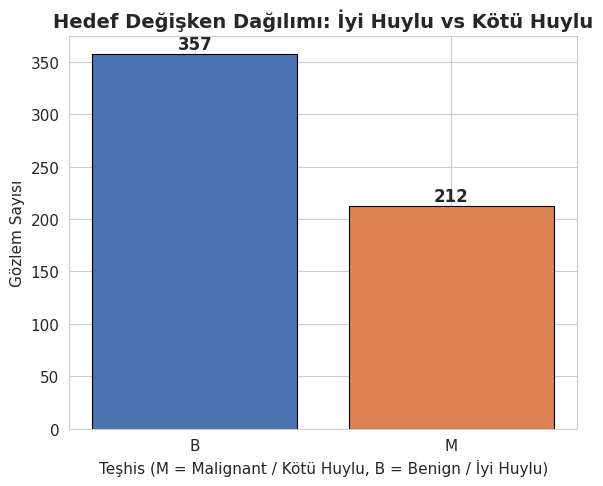

In [13]:
# Visualize the class distribution as a bar chart
# Explicitly map colors to labels to avoid mismatches caused by alphabetical sorting
color_map = {"B": "#4C72B0", "M": "#DD8452"}  # blue = Benign, orange = Malignant
bar_colors = [color_map[label] for label in class_counts.index]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(class_counts.index, class_counts.values, color=bar_colors, edgecolor="black", linewidth=0.8)

# Add count labels on top of each bar
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha="center", fontsize=12, fontweight="bold")

ax.set_title("Hedef Değişken Dağılımı: İyi Huylu vs Kötü Huylu", fontsize=14, fontweight="bold")
ax.set_xlabel("Teşhis (M = Malignant / Kötü Huylu, B = Benign / İyi Huylu)")
ax.set_ylabel("Gözlem Sayısı")
plt.tight_layout()

# Save the figure so we can reuse it in the Medium article and GitHub README
plt.savefig("class_distribution.png", bbox_inches="tight", dpi=150)
plt.show()

### 2.2. Korelasyon Analizi

Özellikler arasındaki ilişkileri görmek için bir korelasyon matrisi oluşturalım. Bu, hem veriyi anlamamıza hem de olası çoklu doğrusal bağlantı (multicollinearity) sorunlarını fark etmemize yardımcı olur. Görselleştirmeyi sadeleştirmek için sadece "mean" (ortalama) grubundaki 10 özelliğe odaklanıyoruz.

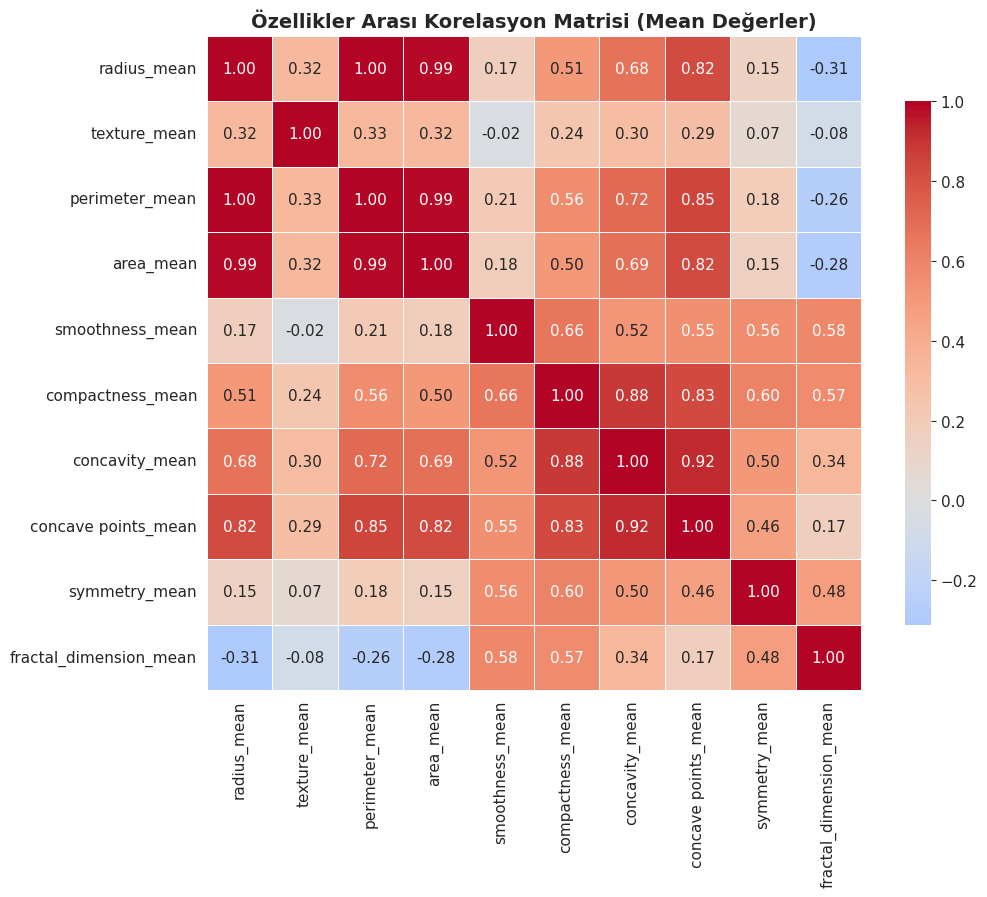

In [14]:
# Compute correlation matrix for the 'mean' features (most interpretable subset)
mean_features = [col for col in df.columns if col.endswith("_mean")]
corr_matrix = df[mean_features].corr()

# Plot the correlation heatmap
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Özellikler Arası Korelasyon Matrisi (Mean Değerler)", fontsize=14, fontweight="bold")
plt.tight_layout()

# Save the figure for later use in Medium article and GitHub README
plt.savefig("correlation_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()

### 2.3. Sınıflara Göre Özellik Dağılımları

Korelasyon analizinden sonra, şimdi en ayırt edici olabilecek birkaç özelliğin iyi huylu ve kötü huylu vakalar arasında nasıl farklılaştığına bakalım. Bunun için boxplot (kutu grafiği) kullanacağız — bu grafik türü, bir dağılımın medyanını, çeyreklik değerlerini ve aykırı değerlerini (outlier) aynı anda görmemizi sağlar.

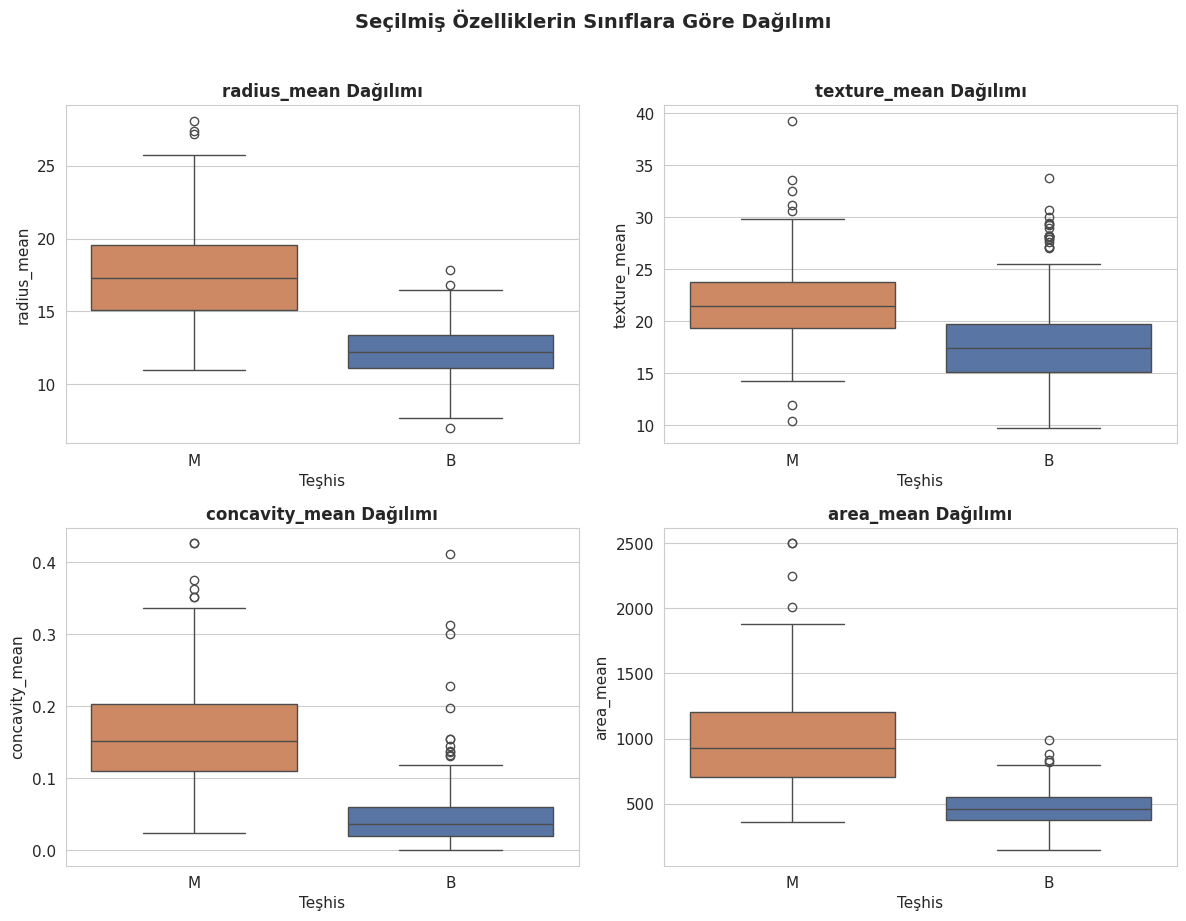

In [15]:
# Compare distributions of key features between the two classes using boxplots
key_features = ["radius_mean", "texture_mean", "concavity_mean", "area_mean"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

# Use the same color mapping as before for visual consistency (B = blue, M = orange)
palette = {"B": "#4C72B0", "M": "#DD8452"}

for i, feature in enumerate(key_features):
    sns.boxplot(data=df, x="diagnosis", y=feature, hue="diagnosis",
                palette=palette, legend=False, ax=axes[i])
    axes[i].set_title(f"{feature} Dağılımı", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Teşhis")

plt.suptitle("Seçilmiş Özelliklerin Sınıflara Göre Dağılımı", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

# Save the figure for later use in Medium article and GitHub README
plt.savefig("feature_boxplots.png", bbox_inches="tight", dpi=150)
plt.show()

**Grafikten çıkardığımız sonuçlar:**

- **`radius_mean` ve `area_mean` çok güçlü ayırt edici özellikler:** Kötü huylu (M) ve iyi huylu (B) gruplarının kutuları neredeyse hiç örtüşmüyor. Özellikle `area_mean`'de M grubunun medyanı yaklaşık (930), B grubunun medyanının (~460) yaklaşık 2 katı — bu, tek başına bile güçlü bir tahmin sinyali olduğunu gösteriyor.
- **`concavity_mean` güçlü ama daha "gürültülü":** M grubu belirgin şekilde daha yüksek değerler alıyor, ancak B grubunda daha fazla aykırı değer (outlier) görülüyor — yani çoğu iyi huylu vaka düşük concavity gösterse de bazı istisnalar var.
- **`texture_mean` en zayıf ayırt edici:** İki grubun kutuları burada daha fazla örtüşüyor. Bu durum, korelasyon analizinde de gördüğümüz gibi `texture_mean`'in diğer özelliklerden bağımsız ve daha az belirleyici bir bilgi taşıdığını doğruluyor.

**Genel çıkarım:** "Büyüklük" temalı özellikler (`radius_mean`, `area_mean`) kötü huylu/iyi huylu ayrımında en güçlü sinyalleri taşıyor gibi görünüyor. Bu ön gözlem, ileride modelin bu özelliklere yüksek önem vermesini bekleyebileceğimize dair bir ipucu veriyor.

## 3️⃣ Veri Ön İşleme

KNN ve SVM gibi **mesafe tabanlı algoritmalar**, özelliklerin ölçeğine (scale) çok duyarlıdır. Örneğin `area_mean` yüzlerce birim değer alırken `smoothness_mean` 0-1 arasında değerler alıyor — ölçeklendirme yapılmazsa, büyük ölçekli özellikler modelde haksız bir baskınlık kurar.

Bu yüzden aşağıdaki adımları izleyeceğiz:
1. Özellikler (X) ve hedef değişkeni (y) ayırma, hedefi sayısala çevirme
2. Eğitim/test setlerine bölme
3. `StandardScaler` ile standartlaştırma (ortalama=0, standart sapma=1)

In [16]:
# Separate features (X) and target (y)
X = df.drop(columns=["diagnosis"])

# Convert the target to numeric: Malignant (M) = 1, Benign (B) = 0
# We use 1 for Malignant because it's the "positive class" we care most about detecting
y = df["diagnosis"].map({"M": 1, "B": 0})

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print("\nTarget value counts:")
print(y.value_counts())

Feature matrix shape: (569, 30)
Target vector shape: (569,)

Target value counts:
diagnosis
0    357
1    212
Name: count, dtype: int64


In [17]:
# Split the dataset into training (80%) and testing (20%) sets
# stratify=y ensures both sets preserve the original class proportions (important for imbalanced-ish data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

print("\nTraining set class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest set class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training set size: 455 samples
Test set size: 114 samples

Training set class distribution:
diagnosis
0    0.626
1    0.374
Name: proportion, dtype: float64

Test set class distribution:
diagnosis
0    0.632
1    0.368
Name: proportion, dtype: float64


In [18]:
# Standardize features: fit the scaler ONLY on training data to avoid data leakage,
# then apply the same transformation to both training and test sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # note: transform only, not fit_transform

print("Feature scaling completed.")
print(f"Mean of scaled training data (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Std of scaled training data (should be ~1): {X_train_scaled.std():.4f}")

Feature scaling completed.
Mean of scaled training data (should be ~0): 0.0000
Std of scaled training data (should be ~1): 1.0000


## 4️⃣ Model 1: K-En Yakın Komşu (K-Nearest Neighbors)

KNN, bir gözlemi sınıflandırırken **en yakın K komşusuna** bakar ve bu komşuların çoğunluk oyuna göre karar verir. Basit ama güçlü bir algoritmadır; en kritik hiperparametresi **K (komşu sayısı)** değeridir.

### 4.1. En İyi K Değerinin Bulunması

Farklı K değerleri için modelin doğruluğunu (5-fold cross-validation ile) karşılaştırarak en uygun K değerini bulacağız. Bu aşamada test setine dokunmuyoruz — sadece eğitim verisi üzerinde çalışıyoruz.

In [19]:
# Test K values from 1 to 30 and record cross-validation accuracy for each
k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    # 5-fold cross-validation on the training set only (test set stays untouched)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring="accuracy")
    cv_scores.append(scores.mean())

# Find the best K value (the one with highest average cross-validation accuracy)
best_k = k_values[np.argmax(cv_scores)]
best_score = max(cv_scores)
print(f"Best K value: {best_k} (Cross-validation accuracy: {best_score:.4f})")

Best K value: 3 (Cross-validation accuracy: 0.9692)


Grafikten, en yüksek çapraz doğrulama doğruluğunu veren K değerini belirledik. Şimdi bu K değeriyle final KNN modelimizi eğitim verisi üzerinde eğitip test seti üzerinde değerlendireceğiz.

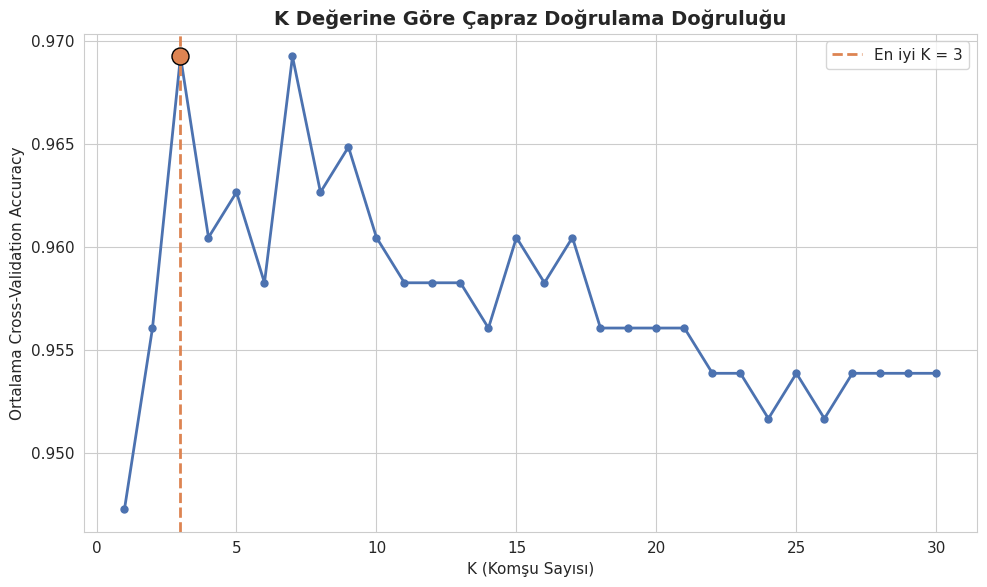

In [20]:
# Plot K value vs cross-validation accuracy
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(k_values, cv_scores, marker="o", linewidth=2, markersize=5, color="#4C72B0")
ax.axvline(x=best_k, color="#DD8452", linestyle="--", linewidth=2, label=f"En iyi K = {best_k}")
ax.scatter([best_k], [best_score], color="#DD8452", s=150, zorder=5, edgecolor="black")

ax.set_title("K Değerine Göre Çapraz Doğrulama Doğruluğu", fontsize=14, fontweight="bold")
ax.set_xlabel("K (Komşu Sayısı)")
ax.set_ylabel("Ortalama Cross-Validation Accuracy")
ax.legend()
plt.tight_layout()

# Save the figure for later use in Medium article and GitHub README
plt.savefig("knn_k_selection.png", bbox_inches="tight", dpi=150)
plt.show()

### 4.2. Final KNN Modelinin Eğitilmesi

En iyi K değerini (K=3) bulduktan sonra, bu değerle final KNN modelimizi eğitim verisi üzerinde eğitip, daha önce hiç görmediği test seti üzerinde tahmin yapmasını sağlıyoruz.

In [21]:
# Train the final KNN model using the best K value found above
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

# Generate predictions on the test set
knn_pred = knn_model.predict(X_test_scaled)
knn_pred_proba = knn_model.predict_proba(X_test_scaled)[:, 1]  # probability of being Malignant (class 1)

print("KNN model trained and predictions generated.")
print(f"Number of test predictions: {len(knn_pred)}")

KNN model trained and predictions generated.
Number of test predictions: 114


## 5️⃣ Model 2: Destek Vektör Makineleri (Support Vector Machine)

SVM, sınıfları birbirinden ayıran **en geniş boşluğu (margin)** bırakan sınırı (hyperplane) bulmaya çalışan güçlü bir algoritmadır. Doğrusal olarak ayrılamayan veriler için **kernel trick** kullanarak veriyi daha yüksek boyutlu bir uzaya taşıyabilir.

### 5.1. En İyi Hiperparametrelerin Bulunması (GridSearchCV)

`C` (regularization / hata toleransı), `kernel` (linear vs rbf) ve `gamma` parametrelerini `GridSearchCV` ile optimize edeceğiz. GridSearchCV, verilen tüm kombinasyonları 5-fold cross-validation ile otomatik olarak dener ve en iyi kombinasyonu bulur.

In [22]:
# Define the hyperparameter grid to search over
param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

# GridSearchCV performs exhaustive search with 5-fold cross-validation
# probability=True is needed later for ROC curve analysis
grid_search = GridSearchCV(
    SVC(probability=True, random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1  # use all available CPU cores to speed up the search
)

grid_search.fit(X_train_scaled, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters found: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9758


### 5.2. Final SVM Modelinin Eğitilmesi

`GridSearchCV` tarafından bulunan en iyi hiperparametrelerle final SVM modelimizi kullanacağız.

In [23]:
# Use the best estimator found by GridSearchCV (already trained on the full training set)
svm_model = grid_search.best_estimator_

# Generate predictions on the test set
svm_pred = svm_model.predict(X_test_scaled)
svm_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1]  # probability of being Malignant (class 1)

print("SVM model trained and predictions generated.")
print(f"Number of test predictions: {len(svm_pred)}")

SVM model trained and predictions generated.
Number of test predictions: 114


## 6️⃣ Model Karşılaştırması ve Değerlendirme

Her iki modelin performansını **accuracy, precision, recall, F1-score, confusion matrix ve ROC-AUC** metrikleriyle karşılaştıracağız.

### 6.1. Temel Performans Metrikleri

Sağlık verisinde sadece accuracy'e bakmak yeterli değildir — özellikle **recall** (gerçek kötü huylu vakaları kaçırmama oranı) kritik önem taşır, çünkü bir kötü huylu vakayı kaçırmak (false negative), yanlış alarm vermekten (false positive) çok daha maliyetli bir hatadır.

In [24]:
def evaluate_model(y_true, y_pred, model_name):
    """Compute and return key classification metrics for a given model."""
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred)
    }

# Evaluate both models on the test set
knn_metrics = evaluate_model(y_test, knn_pred, f"KNN (K={best_k})")
svm_metrics = evaluate_model(y_test, svm_pred, f"SVM ({grid_search.best_params_['kernel']})")

# Combine results into a comparison table
comparison_df = pd.DataFrame([knn_metrics, svm_metrics]).set_index("Model")
comparison_df = comparison_df.round(4)
comparison_df

,Accuracy,Precision,Recall,F1-Score
Model,,,,
KNN (K=3),0.9386,0.973,0.8571,0.9114
SVM (rbf),0.9737,1.000,0.9286,0.9630


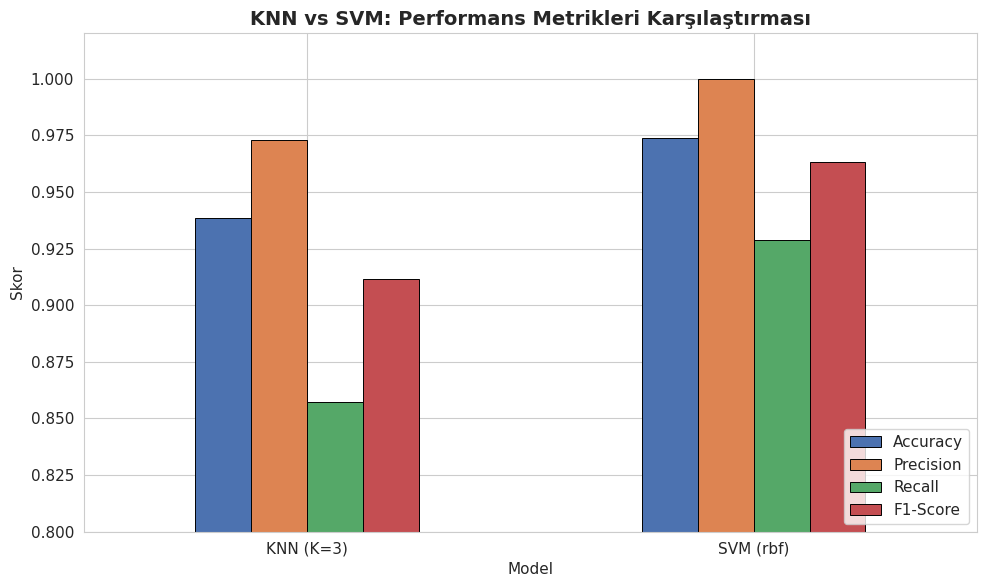

In [25]:
# Visualize the metric comparison as a grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
                    edgecolor="black", linewidth=0.7)

ax.set_title("KNN vs SVM: Performans Metrikleri Karşılaştırması", fontsize=14, fontweight="bold")
ax.set_ylabel("Skor")
ax.set_ylim(0.8, 1.02)
ax.legend(loc="lower right")
ax.set_xticklabels(comparison_df.index, rotation=0)
plt.tight_layout()

# Save the figure for later use in Medium article and GitHub README
plt.savefig("metrics_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

### 6.2. Confusion Matrix (Karışıklık Matrisi) Karşılaştırması

Confusion matrix, modelin hangi sınıfları ne sıklıkla doğru/yanlış tahmin ettiğini gösterir. Özellikle sağlık alanında **false negative** (kötü huylu bir vakayı iyi huylu olarak tahmin etmek) çok kritik bir hatadır, bu yüzden bu matrise dikkatle bakmak önemli.

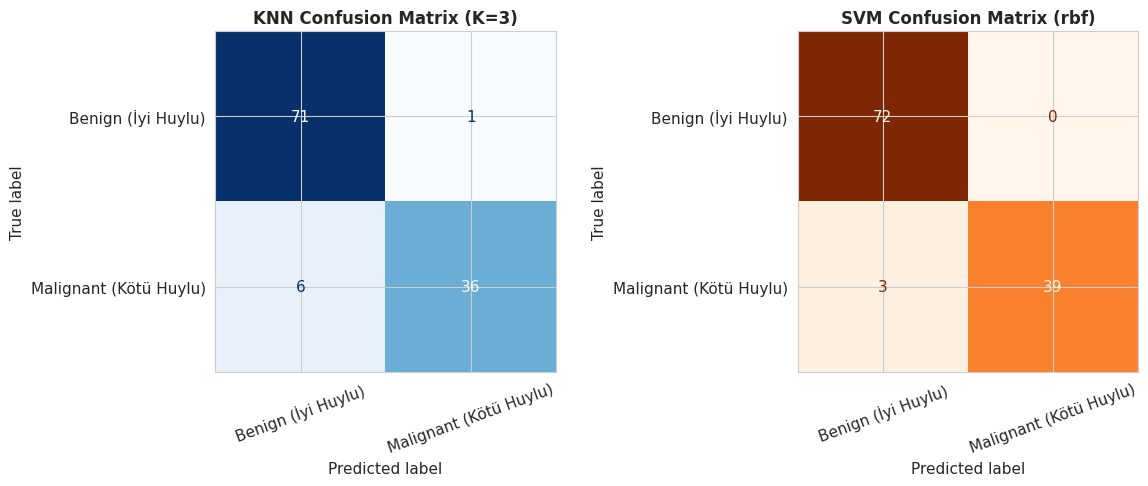

In [26]:
# Plot confusion matrices for both models side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Benign (İyi Huylu)", "Malignant (Kötü Huylu)"]  # 0 = Benign, 1 = Malignant

cm_knn = confusion_matrix(y_test, knn_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=labels)
disp_knn.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"KNN Confusion Matrix (K={best_k})", fontsize=12, fontweight="bold")
axes[0].tick_params(axis='x', rotation=20)

cm_svm = confusion_matrix(y_test, svm_pred)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=labels)
disp_svm.plot(ax=axes[1], cmap="Oranges", colorbar=False)
axes[1].set_title(f"SVM Confusion Matrix ({grid_search.best_params_['kernel']})", fontsize=12, fontweight="bold")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()

# Save the figure for later use in Medium article and GitHub README
plt.savefig("confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()

### 6.3. ROC Eğrisi Karşılaştırması

ROC (Receiver Operating Characteristic) eğrisi, modelin farklı eşik (threshold) değerlerinde true positive rate (recall) ve false positive rate arasındaki dengeyi gösterir. **AUC (Area Under Curve)** değeri 1'e ne kadar yakınsa model o kadar başarılıdır; 0.5 ise modelin rastgele tahminden farksız olduğu anlamına gelir.

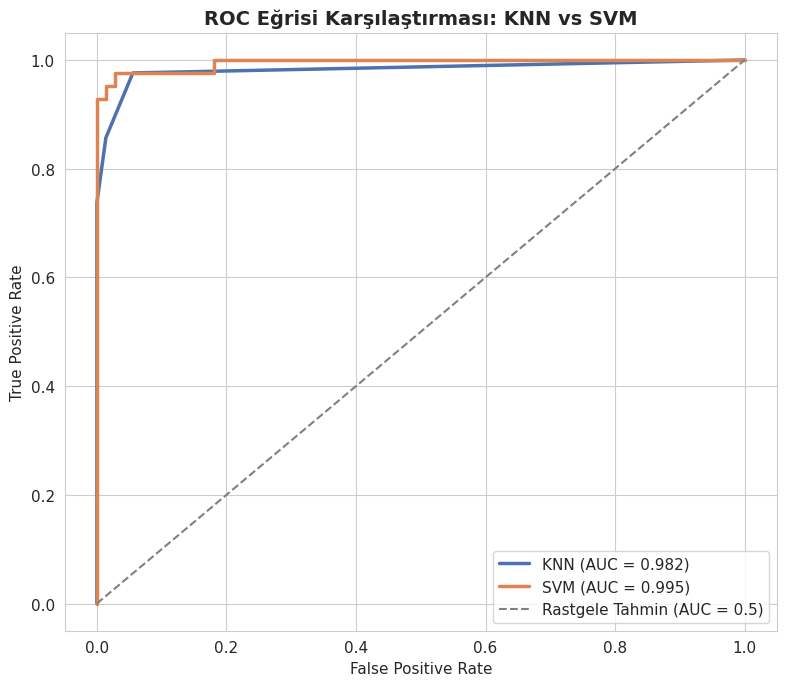

In [27]:
# Compute ROC curve and AUC for both models
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_pred_proba)
auc_knn = auc(fpr_knn, tpr_knn)

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_pred_proba)
auc_svm = auc(fpr_svm, tpr_svm)

# Plot both ROC curves on the same chart for direct comparison
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr_knn, tpr_knn, linewidth=2.5, color="#4C72B0", label=f"KNN (AUC = {auc_knn:.3f})")
ax.plot(fpr_svm, tpr_svm, linewidth=2.5, color="#DD8452", label=f"SVM (AUC = {auc_svm:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Rastgele Tahmin (AUC = 0.5)")

ax.set_title("ROC Eğrisi Karşılaştırması: KNN vs SVM", fontsize=14, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
plt.tight_layout()

# Save the figure for later use in Medium article and GitHub README
plt.savefig("roc_curve_comparison.png", bbox_inches="tight", dpi=150)
plt.show()

### 6.4. Karar Sınırı Görselleştirmesi (2 Boyutlu)

Modellerin karar mantığını daha iyi görebilmek için, en ayırt edici iki özelliği (`radius_worst` ve `concave points_worst`) kullanarak 2 boyutlu bir karar sınırı görselleştirmesi yapalım. Bu, SVM ve KNN'in sınıfları nasıl farklı şekillerde ayırdığını görsel olarak göstermek için hazırlanmış, sadeleştirilmiş bir örnektir — ana modellerimiz hâlâ 30 özellik kullanıyor.

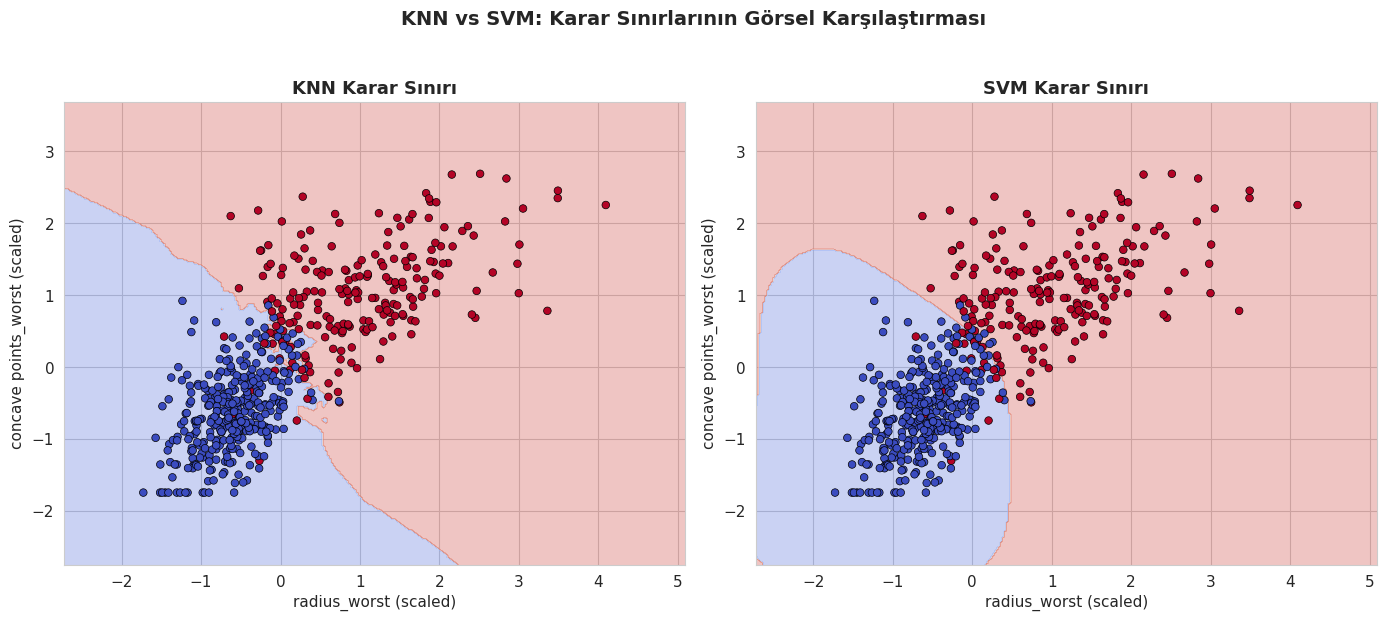

In [28]:
# Select two of the most discriminative features for 2D visualization
feat_x, feat_y = "radius_worst", "concave points_worst"
X_2d = df[[feat_x, feat_y]].values
y_2d = y.values  # already numeric: 0 = Benign, 1 = Malignant

# Scale the 2D data (same reasoning as before: distance-based models need scaled features)
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

# Train simplified 2D versions of both models, using the same tuned hyperparameters (for visualization only)
knn_2d = KNeighborsClassifier(n_neighbors=best_k).fit(X_2d_scaled, y_2d)
svm_2d = SVC(kernel=grid_search.best_params_["kernel"],
             C=grid_search.best_params_["C"],
             gamma=grid_search.best_params_["gamma"]).fit(X_2d_scaled, y_2d)

# Create a mesh grid to plot decision boundaries
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, title in zip(axes, [knn_2d, svm_2d], ["KNN Karar Sınırı", "SVM Karar Sınırı"]):
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = ax.scatter(X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap="coolwarm",
                          edgecolor="black", linewidth=0.5, s=30)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel(f"{feat_x} (scaled)")
    ax.set_ylabel(f"{feat_y} (scaled)")

plt.suptitle("KNN vs SVM: Karar Sınırlarının Görsel Karşılaştırması", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()

# Save the figure for later use in Medium article and GitHub README
plt.savefig("decision_boundaries.png", bbox_inches="tight", dpi=150)
plt.show()

Görsel karşılaştırma, **KNN'in daha "düzensiz/lokal" bir sınır çizdiğini**, **SVM'in ise daha "pürüzsüz ve genel" bir sınır çizdiğini** gösteriyor. KNN'in sınırındaki küçük kıvrımlar, modelin eğitim verisindeki lokal örüntülere/istisnalara daha fazla uyum sağlamaya çalıştığını yansıtıyor — bu da hafif bir overfitting eğilimine işaret edebilir. SVM'in daha genel yaklaşımı ise, önceki bölümde gördüğümüz daha yüksek recall ve precision skorlarını görsel olarak da açıklıyor.

## 7️⃣ Sonuç ve Çıkarımlar

### 📋 Özet Bulgular

Bu projede, **Breast Cancer Wisconsin (Diagnostic) Dataset** üzerinde iki farklı sınıflandırma algoritması (KNN ve SVM) eğitilmiş ve karşılaştırılmıştır.

**Ana çıkarımlar:**

1. **Veri Kalitesi:** Veri setinde eksik değer bulunmaması ve sınıfların makul bir dengede olması (%62.7 İyi Huylu - %37.3 Kötü Huylu), modelleme sürecini kolaylaştırmıştır.

2. **Özellik İlişkileri:** `radius_mean`, `area_mean`, `perimeter_mean` gibi büyüklük odaklı özellikler birbiriyle çok yüksek korelasyon göstermiş (0.99'a kadar); `concavity` ve `concave points` gibi şekil odaklı özellikler ise kötü huylu vakalarda belirgin şekilde daha yüksek değerler almıştır. `texture_mean` ise diğer özelliklerden bağımsız, kendine özgü bir bilgi taşıdığı için ayrıca dikkat çekicidir.

3. **Hiperparametre Optimizasyonu Fark Yarattı:** KNN için 30 farklı K değeri test edilerek en iyi K=3 bulunmuş (cross-validation accuracy: %96.9); SVM için GridSearchCV ile C, kernel ve gamma kombinasyonları taranarak en iyi kombinasyon C=1, kernel=rbf, gamma=scale olarak belirlenmiştir (cross-validation accuracy: %97.6).

4. **Model Performansı:** Test seti üzerinde **SVM (rbf kernel), KNN'e göre tüm metriklerde daha başarılı** olmuştur:

   | Model | Accuracy | Precision | Recall | F1-Score | AUC |
   |---|---|---|---|---|---|
   | KNN (K=3) | %93.9 | %97.3 | %85.7 | 0.911 | 0.982 |
   | SVM (rbf) | %97.4 | %100.0 | %92.9 | 0.963 | 0.995 |

   Özellikle **recall** farkı klinik açıdan anlamlıdır: KNN test setindeki 42 kötü huylu vakadan 6'sını kaçırırken (false negative), SVM sadece 3'ünü kaçırmıştır. SVM ayrıca hiç false positive üretmemiştir (precision = %100).

5. **Ölçeklendirmenin Önemi:** Hem KNN hem de SVM mesafe/margin tabanlı algoritmalar olduğu için `StandardScaler` ile özellik ölçeklendirmesi, model performansı açısından kritik bir adım olmuştur.

6. **Karar Sınırı Farkları:** Görselleştirmeler, KNN'in daha lokal/esnek bir karar sınırı çizerken, SVM'in daha genel ve pürüzsüz bir sınır oluşturduğunu göstermiştir. Bu fark, SVM'in bu veri setinde neden daha az hata yaptığını görsel olarak da açıklamaktadır.

### 🔮 Geliştirme Fikirleri

- Random Forest veya Gradient Boosting gibi ek algoritmalar eklenerek karşılaştırma genişletilebilir.
- Özellik seçimi (feature selection) teknikleri ile modelin daha az ama daha anlamlı özellikle çalışması sağlanabilir.
- Daha geniş bir veri seti veya farklı hastane/popülasyonlardan toplanmış verilerle modelin genellenebilirliği test edilebilir.
- SHAP veya LIME gibi açıklanabilirlik (explainability) teknikleriyle modelin bireysel tahminleri daha derinlemesine incelenebilir.

---

*Bu proje, Türkiye Yapay Zeka Akademisi ve Huawei Student Developers iş birliğiyle yürütülen Veri Bilimi ve Makine Öğrenmesi Bootcamp'i kapsamında hazırlanmıştır.*